## Importing libraries

In [1]:
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
from model import unet

## Getting image paths

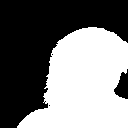

In [4]:
train_data_path = './Images/Train'
test_data_path = './Images/Test/'

train_images_path = os.path.join(train_data_path, 'Images')
train_masks_path = os.path.join(train_data_path, 'Masks')

test_images_path = os.path.join(test_data_path, 'Images')
test_masks_path = os.path.join(test_data_path, 'Masks')

image_names = os.listdir(train_images_path)
test_image_names = os.listdir(test_images_path)

train_images = [os.path.join(train_images_path, image_name) for image_name in image_names]
train_masks = [os.path.join(train_masks_path, image_name) for image_name in image_names]

test_images = [os.path.join(test_images_path, image_name) for image_name in test_image_names]
test_masks = [os.path.join(test_masks_path, image_name) for image_name in test_image_names]

example_mask = tf.keras.utils.load_img(train_masks[0])
example_mask

## Loading training data

In [5]:
X_train = []
y_train = []

for i in range(0, len(train_images)):
    img = tf.keras.utils.load_img(train_images[i])
    img = tf.keras.utils.img_to_array(img)
    X_train.append(img)

    mask = tf.keras.utils.load_img(train_masks[i], color_mode='grayscale')
    mask = tf.keras.utils.img_to_array(mask)
    y_train.append(mask)

    if (i+1)%100 == 0 or i==len(train_images)-1:
        print(f"\r{i+1}/{len(train_images)} images loaded...", end='')

X_train = np.array(X_train)
y_train = np.array(y_train)
y_train_scaled = y_train/255.

18600/18698 images loaded...

## Loading test data

In [6]:
X_test = []
y_test = []

for i in range(0, len(test_images)):
    img = tf.keras.utils.load_img(test_images[i])
    img = tf.keras.utils.img_to_array(img)
    X_test.append(img)

    mask = tf.keras.utils.load_img(test_masks[i], color_mode='grayscale')
    mask = tf.keras.utils.img_to_array(mask)
    y_test.append(mask)

    if (i+1)%100 == 0 or i==len(test_images)-1:
        print(f"\r{i+1}/{len(test_images)} images loaded...", end='')

X_test = np.array(X_test)
y_test = np.array(y_test)
y_test_scaled = y_test/255.

3700/3740 images loaded...

In [7]:
X_train.shape, y_train.shape, np.unique(y_train[0])

((18698, 128, 128, 3),
 (18698, 128, 128, 1),
 array([  0., 255.], dtype=float32))

## Defining Model architecture and Compiling the model

In [ ]:
model = unet(input_shape=X_train.shape[1:], is_inside_notebook=True, filters=16)

## Show one example image along with its mask

In [ ]:
plt.imshow(X_train[0].astype(int))
plt.show()
plt.imshow(y_train_scaled[0])
plt.show()

## Defining Custom Callback for Early Stopping

In [17]:
class EarlyStoppingCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs):
        if logs['accuracy'] > 0.99 and logs['val_accuracy'] > 0.99:
            self.model.stop_training = True

## Train the model and make predictions

In [11]:
history = model.fit(X_train, y_train_scaled, epochs=10, validation_split=0.1, callbacks=[EarlyStoppingCallback()])

Epoch 1/10
526/526 ━━━━━━━━━━━━━━━━━━━━ 426s 795ms/step - accuracy: 0.8500 - loss: 0.3366 - val_accuracy: 0.9232 - val_loss: 0.1938
Epoch 2/10
526/526 ━━━━━━━━━━━━━━━━━━━━ 532s 1s/step - accuracy: 0.9367 - loss: 0.1626 - val_accuracy: 0.9523 - val_loss: 0.1261
Epoch 3/10
526/526 ━━━━━━━━━━━━━━━━━━━━ 497s 945ms/step - accuracy: 0.9536 - loss: 0.1222 - val_accuracy: 0.9584 - val_loss: 0.1102
Epoch 4/10
526/526 ━━━━━━━━━━━━━━━━━━━━ 486s 925ms/step - accuracy: 0.9609 - loss: 0.1037 - val_accuracy: 0.9681 - val_loss: 0.0858
Epoch 5/10
526/526 ━━━━━━━━━━━━━━━━━━━━ 464s 882ms/step - accuracy: 0.9661 - loss: 0.0900 - val_accuracy: 0.9685 - val_loss: 0.0849
Epoch 6/10
526/526 ━━━━━━━━━━━━━━━━━━━━ 478s 909ms/step - accuracy: 0.9697 - loss: 0.0799 - val_accuracy: 0.9726 - val_loss: 0.0741
Epoch 7/10
526/526 ━━━━━━━━━━━━━━━━━━━━ 459s 872ms/step - accuracy: 0.9732 - loss: 0.0706 - val_accuracy: 0.9743 - val_loss: 0.0728
Epoch 8/10
526/526 ━━━━━━━━━━━━━━━━━━━━ 469s 891ms/step - accuracy: 0.9750 - lo

In [12]:
img_path = './Images/test_image/test6.jpg'
img = tf.keras.utils.img_to_array(tf.keras.utils.load_img(img_path, target_size=(128, 128)))
test_image = np.expand_dims(img, axis=0)

In [13]:
pred = model.predict(test_image)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 519ms/step


In [14]:
# Optional : Create a mask by thresholding
mask = (pred > 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


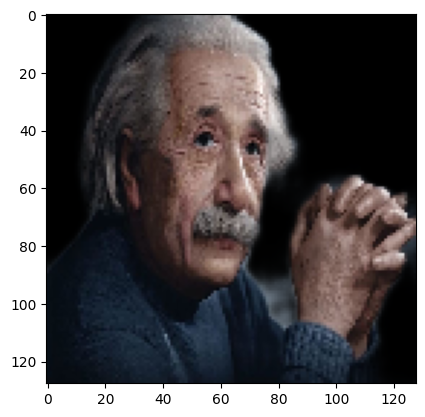

In [15]:
plt.imshow(img/255. * model.predict(test_image)[0])
plt.show()

## Evaluate, Save and Load Model

In [16]:
evaluation = model.evaluate(np.array(X_test), y_test_scaled)

117/117 ━━━━━━━━━━━━━━━━━━━━ 39s 333ms/step - accuracy: 0.9808 - loss: 0.0540


In [21]:
model.save('model_v2.keras')